# EDA

In [1]:
import polars as pl
import matplotlib.pyplot as plt
SALES_FILE_PATH = "..\\data\\silver\\sales.parquet"


sales_df = pl.scan_parquet(SALES_FILE_PATH)
sales_df.show()



id,item_id,dept_id,cat_id,store_id,state_id,d,sales,date,wm_yr_wk,weekday,wday,month,year,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI,sell_price
str,str,str,str,str,str,str,i64,str,i64,str,i64,i64,i64,str,str,str,str,i64,i64,i64,f64
"""HOBBIES_1_238_CA_1_evaluation""","""HOBBIES_1_238""","""HOBBIES_1""","""HOBBIES""","""CA_1""","""CA""","""d_1""",1,"""2011-01-29""",11101,"""Saturday""",1,1,2011,null,null,null,null,0,0,0,5.94
"""HOBBIES_1_266_CA_1_evaluation""","""HOBBIES_1_266""","""HOBBIES_1""","""HOBBIES""","""CA_1""","""CA""","""d_1""",0,"""2011-01-29""",11101,"""Saturday""",1,1,2011,null,null,null,null,0,0,0,null
"""HOBBIES_1_272_CA_1_evaluation""","""HOBBIES_1_272""","""HOBBIES_1""","""HOBBIES""","""CA_1""","""CA""","""d_1""",0,"""2011-01-29""",11101,"""Saturday""",1,1,2011,null,null,null,null,0,0,0,null
"""HOBBIES_1_275_CA_1_evaluation""","""HOBBIES_1_275""","""HOBBIES_1""","""HOBBIES""","""CA_1""","""CA""","""d_1""",0,"""2011-01-29""",11101,"""Saturday""",1,1,2011,null,null,null,null,0,0,0,null
"""HOBBIES_1_284_CA_1_evaluation""","""HOBBIES_1_284""","""HOBBIES_1""","""HOBBIES""","""CA_1""","""CA""","""d_1""",0,"""2011-01-29""",11101,"""Saturday""",1,1,2011,null,null,null,null,0,0,0,null


In [2]:
result = (
    sales_df
    .select([
        "item_id",
        "dept_id",
        "cat_id",
        "store_id",
        "year",
        'date',
        "sales",
        "sell_price"
    ])
    .group_by([
        "item_id",
        "store_id",
        "year",
        "date"
    ])
    .agg([
        pl.sum("sales").alias("daily_sales"),
        pl.mean("sell_price").alias("avg_sell_price")
    ])
    .sort([
        "item_id",
        "store_id",
        "date"
    ])
)

In [3]:
daily_summary = (
    result.collect()
    .group_by(["year", "date"])
    .agg([
        pl.sum("daily_sales").alias("total_daily_sales"),
        pl.mean("avg_sell_price").alias("daily_avg_price")
    ])
    .sort("date")
)

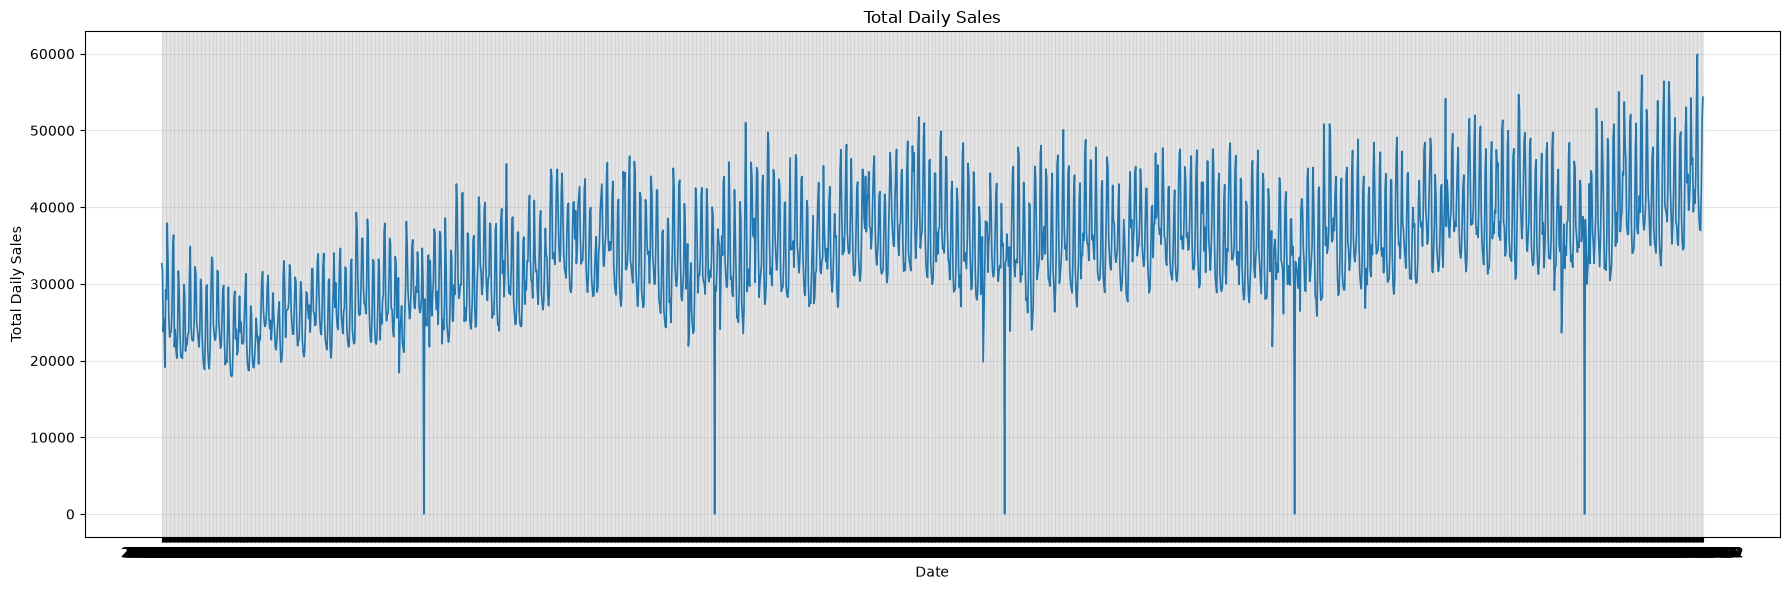

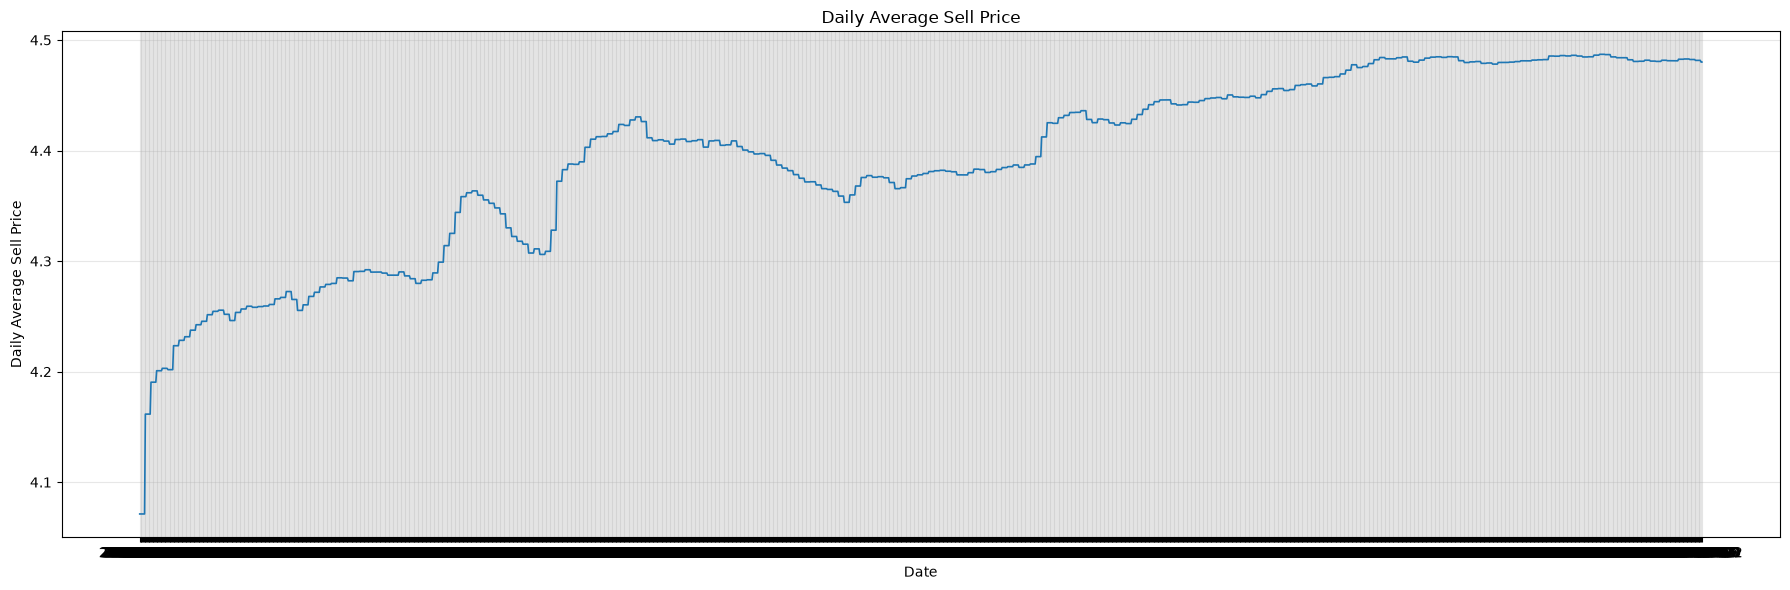

In [4]:

# Daily total sales
plt.figure(figsize=(18, 6))

plt.plot(
    daily_summary["date"].to_numpy(),
    daily_summary["total_daily_sales"].to_numpy(),
    linewidth=1.2
)

plt.xlabel("Date")
plt.ylabel("Total Daily Sales")
plt.title(f"Total Daily Sales")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Daily average price
plt.figure(figsize=(18, 6))

plt.plot(
    daily_summary["date"].to_numpy(),
    daily_summary["daily_avg_price"].to_numpy(),
    linewidth=1.2
)

plt.xlabel("Date")
plt.ylabel("Daily Average Sell Price")
plt.title(f"Daily Average Sell Price")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.seasonal import STL
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller


ts_df = (
    daily_summary
    .select([
        "date",
        "total_daily_sales",
        "daily_avg_price"
    ])
    .sort("date")
    .to_pandas()
)

ts_df["date"] = pd.to_datetime(ts_df["date"])

ts_df = ts_df.set_index("date")

# Ensure one observation per day
# ts_df = ts_df.asfreq("D")

ts_df.head()


,total_daily_sales,daily_avg_price
date,,
2011-01-29,32631,4.071247
2011-01-30,31749,4.071247
2011-01-31,23783,4.071247
2011-02-01,25412,4.071247
2011-02-02,19146,4.071247


In [6]:
ts_df.isna().sum()

total_daily_sales    0
daily_avg_price      0
dtype: int64

In [7]:
# Sales: if a missing date really means no recorded sales
sales_ts = ts_df["total_daily_sales"].fillna(0)

# Price: interpolate missing average prices
price_ts = (
    ts_df["daily_avg_price"]
    .interpolate(method="time")
    .ffill()
    .bfill()
)

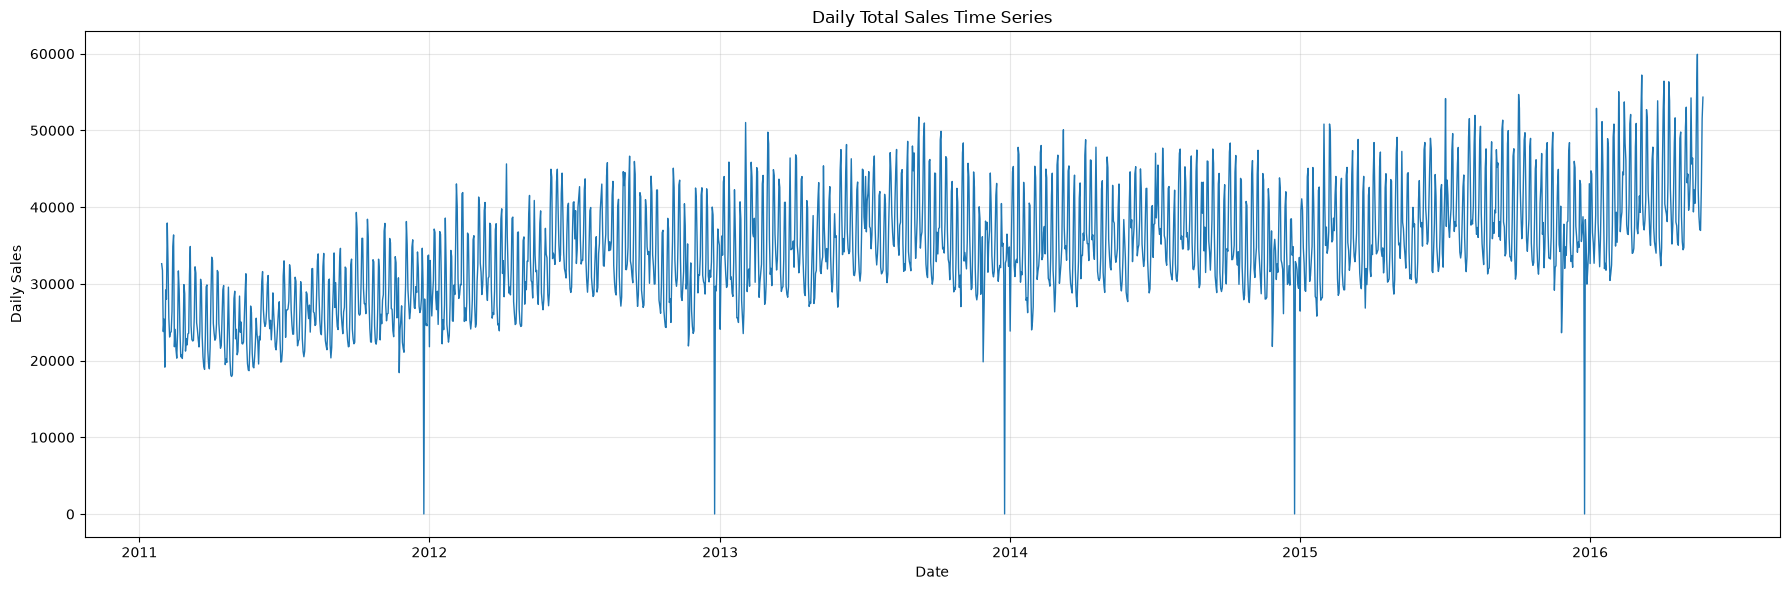

In [8]:
plt.figure(figsize=(18, 6))

plt.plot(
    sales_ts.index,
    sales_ts.values,
    linewidth=1
)

plt.xlabel("Date")
plt.ylabel("Daily Sales")
plt.title("Daily Total Sales Time Series")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

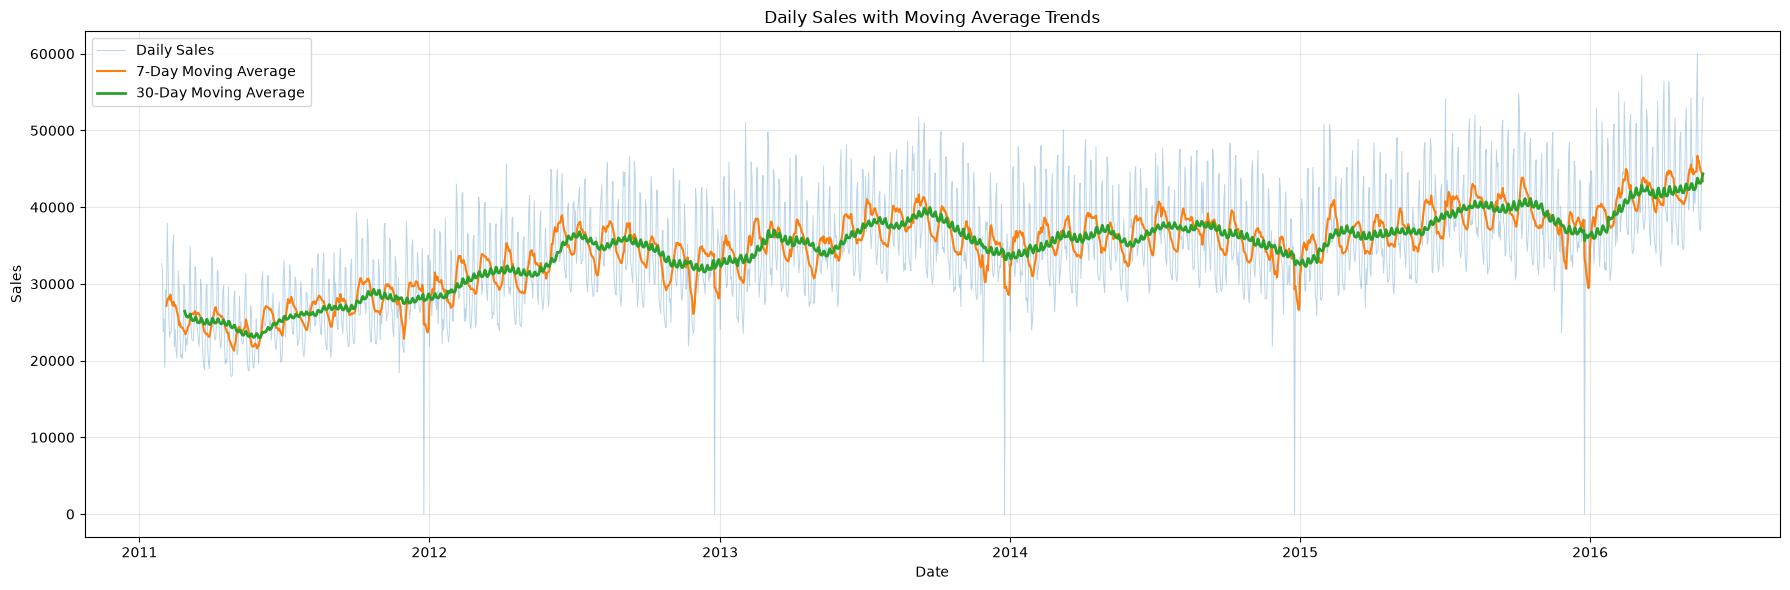

In [14]:
sales_7d = sales_ts.rolling(window=7).mean()
sales_30d = sales_ts.rolling(window=30).mean()

plt.figure(figsize=(18, 6))

plt.plot(
    sales_ts.index,
    sales_ts,
    alpha=0.3,
    linewidth=0.7,
    label="Daily Sales"
)

plt.plot(
    sales_7d.index,
    sales_7d,
    linewidth=1.5,
    label="7-Day Moving Average"
)

plt.plot(
    sales_30d.index,
    sales_30d,
    linewidth=2,
    label="30-Day Moving Average"
)


plt.xlabel("Date")
plt.ylabel("Sales")
plt.title("Daily Sales with Moving Average Trends")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

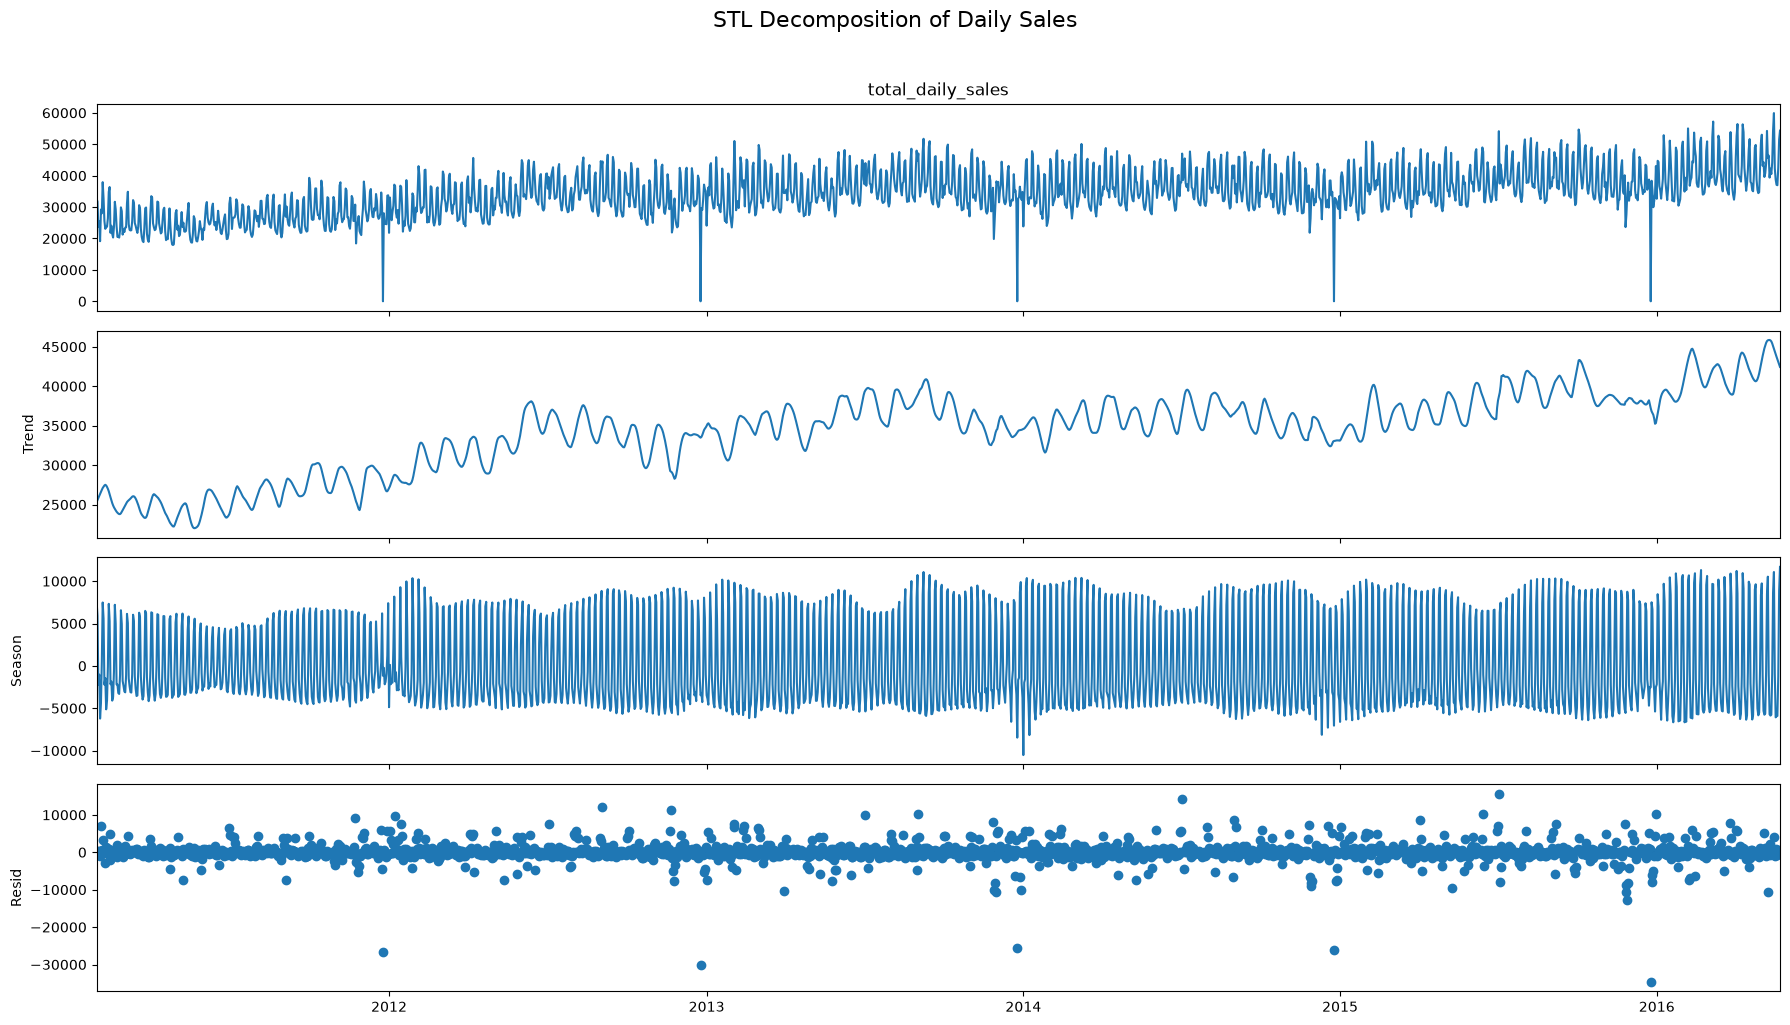

In [ ]:
sales_stl = STL(
    sales_ts,
    period=7,
    robust=True
)

sales_result = sales_stl.fit()

sales_result.plot()

plt.gcf().set_size_inches(18, 10)
plt.suptitle(
    "STL Decomposition of Daily Sales",
    fontsize=16,
    y=1.02
)

plt.tight_layout()
plt.show()

In [18]:
sales_trend = sales_result.trend
sales_seasonal = sales_result.seasonal
sales_residual = sales_result.resid

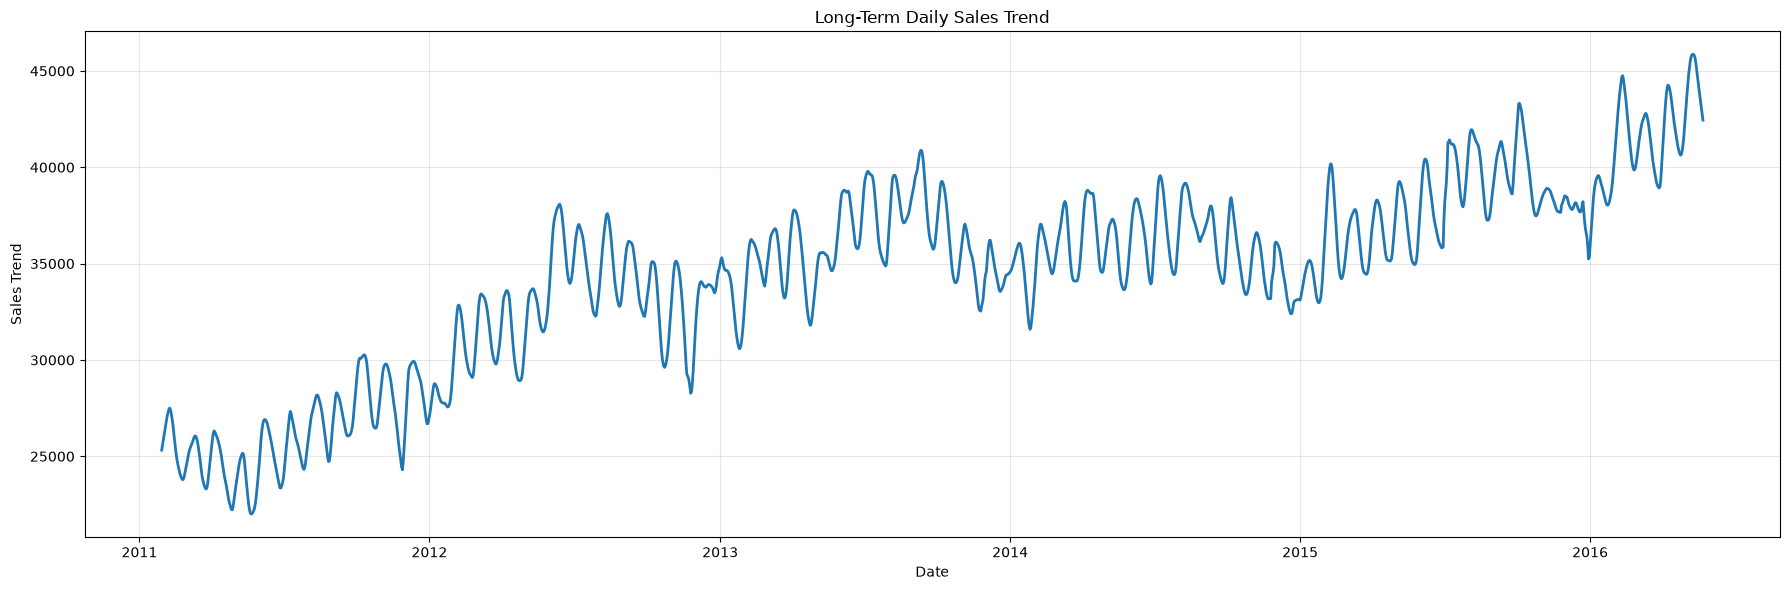

In [19]:
plt.figure(figsize=(18, 6))

plt.plot(
    sales_trend.index,
    sales_trend.values,
    linewidth=2
)

plt.xlabel("Date")
plt.ylabel("Sales Trend")
plt.title("Long-Term Daily Sales Trend")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

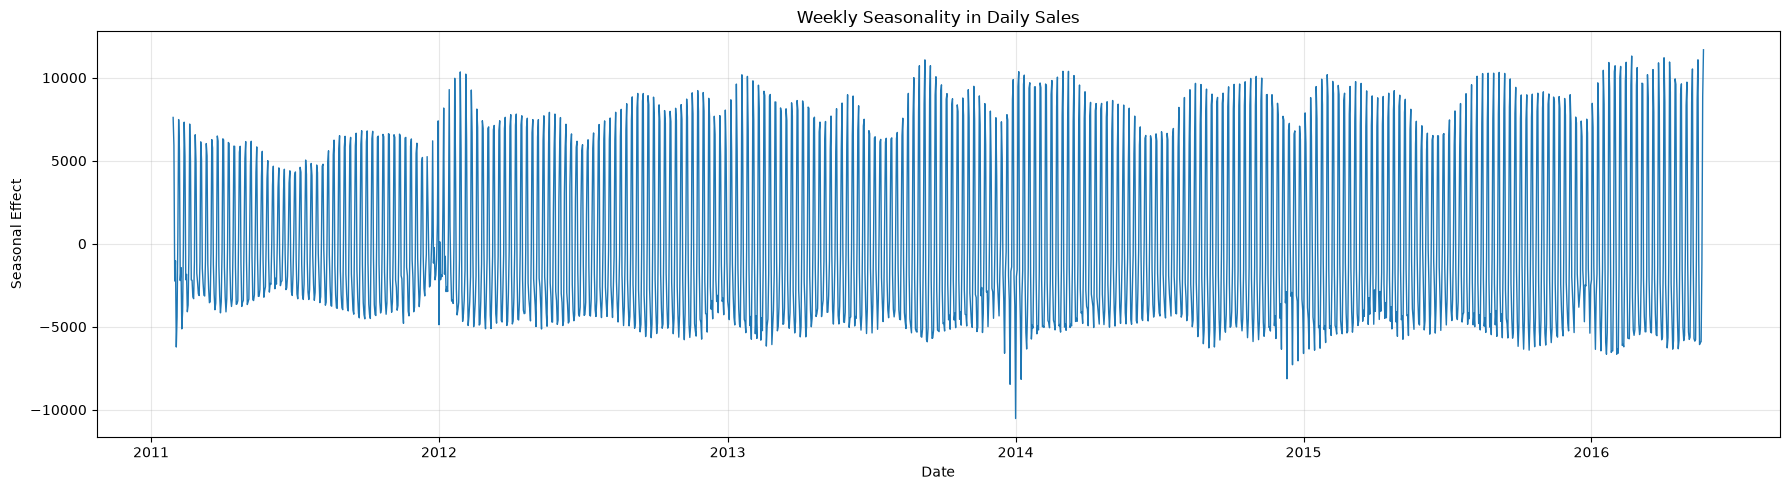

In [20]:
plt.figure(figsize=(18, 5))

plt.plot(
    sales_seasonal.index,
    sales_seasonal.values,
    linewidth=1
)

plt.xlabel("Date")
plt.ylabel("Seasonal Effect")
plt.title("Weekly Seasonality in Daily Sales")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

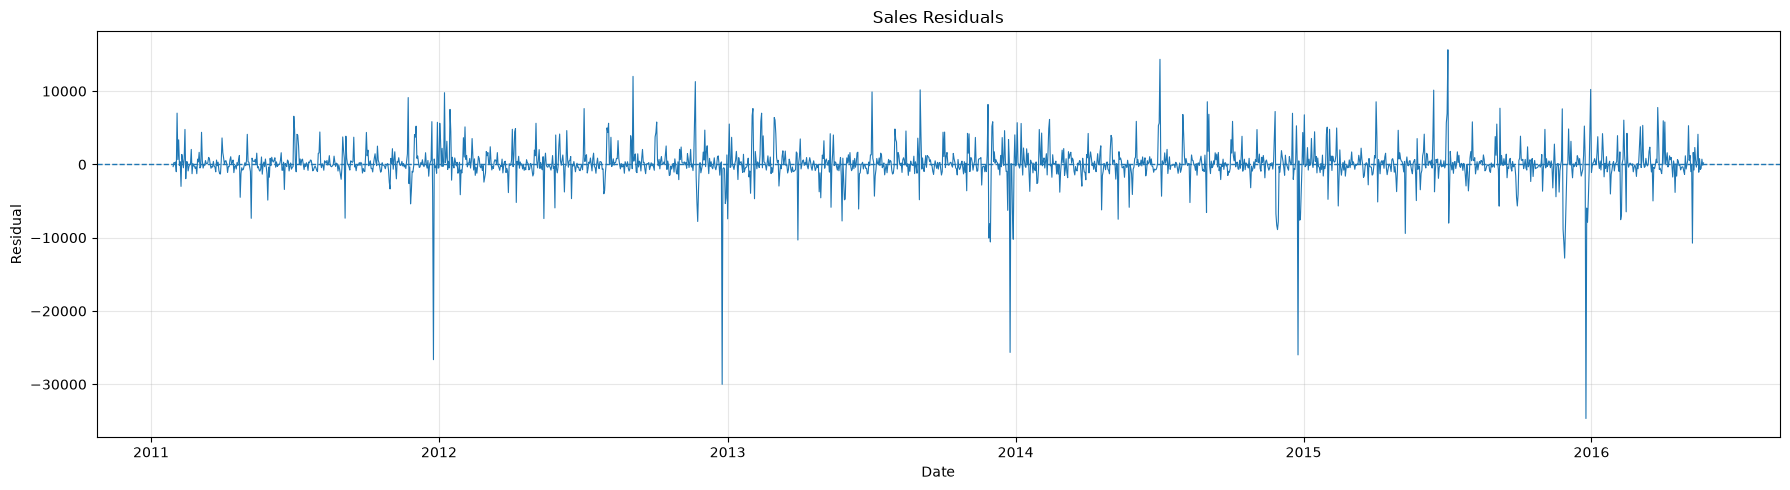

In [21]:
plt.figure(figsize=(18, 5))

plt.plot(
    sales_residual.index,
    sales_residual.values,
    linewidth=0.8
)

plt.axhline(
    y=0,
    linestyle="--",
    linewidth=1
)

plt.xlabel("Date")
plt.ylabel("Residual")
plt.title("Sales Residuals")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

<Figure size 1600x600 with 0 Axes>

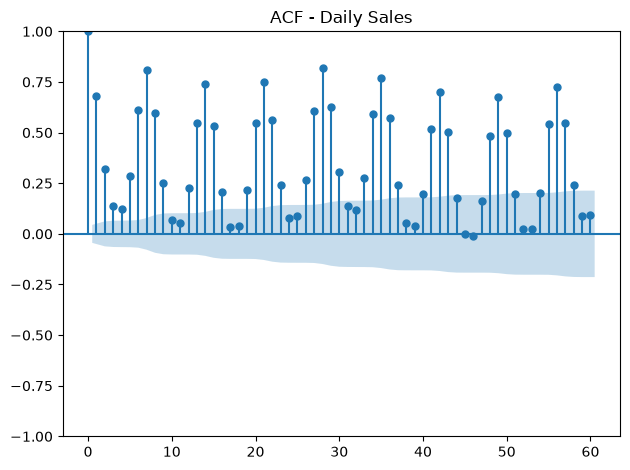

In [29]:
plt.figure(figsize=(16, 6))

plot_acf(
    sales_ts,
    lags=60
)

plt.title("ACF - Daily Sales")
plt.tight_layout()
plt.show()

<Figure size 1600x600 with 0 Axes>

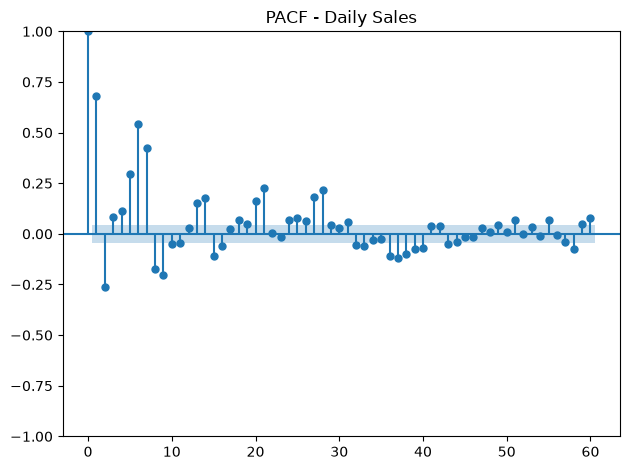

In [ ]:
plt.figure(figsize=(16, 6))

plot_pacf(
    sales_ts,
    lags=60,
    method="ywm"
)

plt.title("PACF - Daily Sales")
plt.tight_layout()
plt.show()

In [33]:
adf_result = adfuller(
        sales_ts.dropna()
    )

print("ADF Statistic:", adf_result[0])
print("p-value:", adf_result[1])

print("\nCritical Values:")

for key, value in adf_result[4].items():
    print(f"{key}: {value}")

print('\n')
    
if adf_result[1] < 0.05:
    print("Series appears stationary")
else:
    print("Series appears non-stationary")

ADF Statistic: -1.2960840275853232
p-value: 0.6309619660319115

Critical Values:
1%: -3.4337711555892523
5%: -2.8630512450631986
10%: -2.567574528530358


Series appears non-stationary


In [ ]:
from statsmodels.tsa.stattools import kpss

kpss_result = kpss(
    sales_ts.dropna(),
    regression="c",
    nlags="auto"
)

print("KPSS Statistic:", kpss_result[0])
print("p-value:", kpss_result[1])

print()

if kpss_result[1] > 0.05:
    print("Series appears stationary")
else:
    print("Series appears non-stationary")

KPSS Statistic: 6.578444212479125
p-value: 0.01

Series appears non-stationary


C:\Users\thilo\AppData\Local\Temp\ipykernel_8372\4144455269.py:3: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_result = kpss(


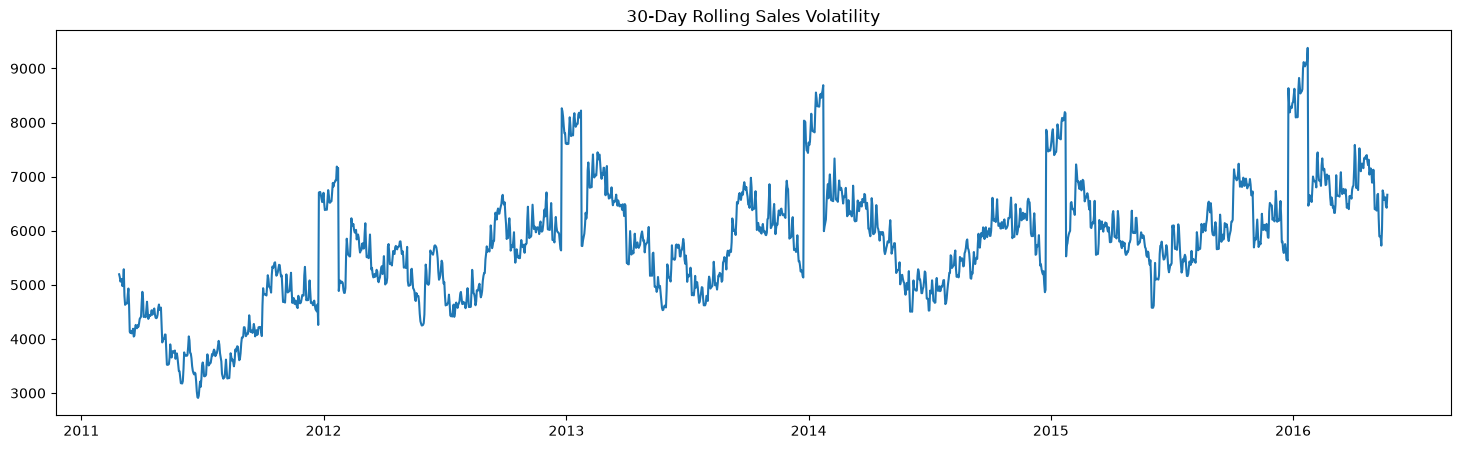

In [58]:
rolling_std = (
    sales_ts
    .rolling(30)
    .std()
)

plt.figure(figsize=(18, 5))

plt.plot(rolling_std)

plt.title("30-Day Rolling Sales Volatility")
plt.show()

### Seventh Day Difference

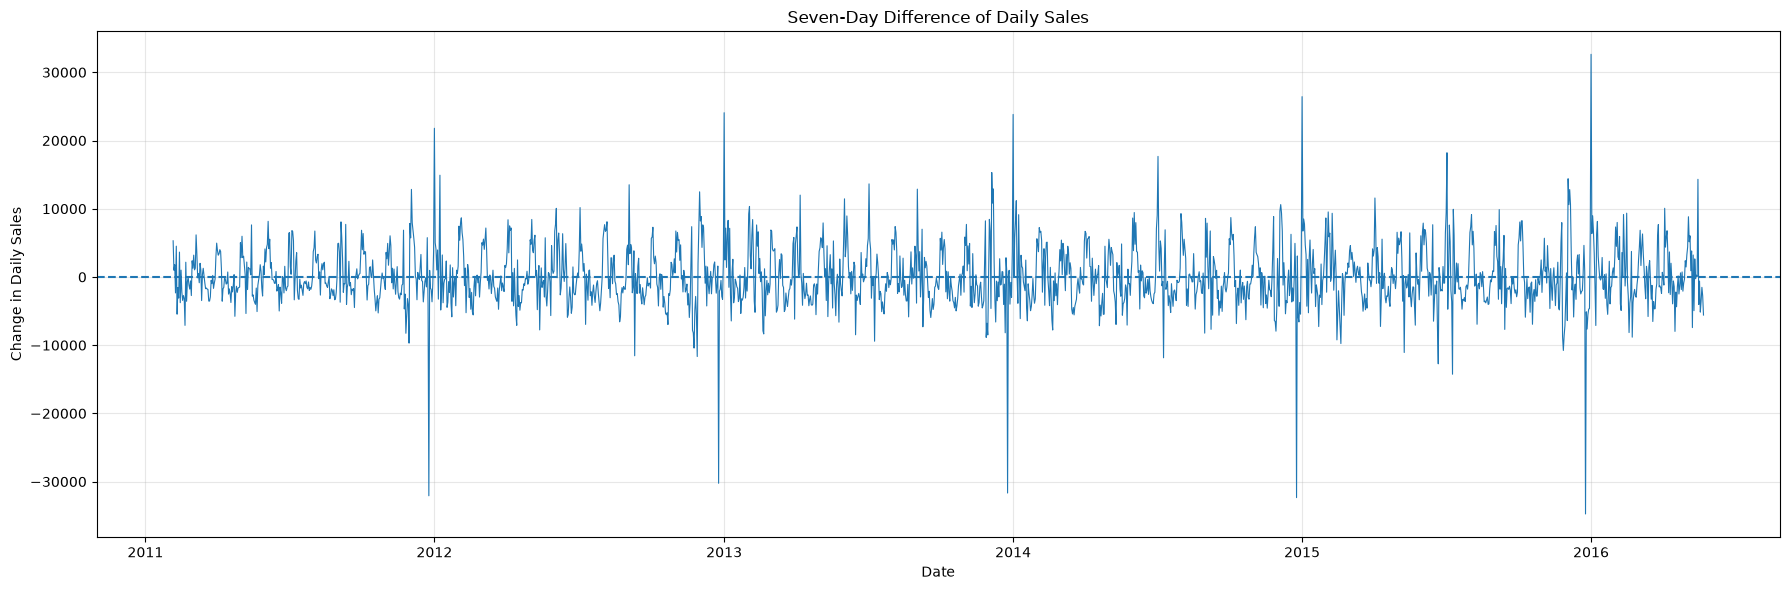

In [62]:
sales_diff = sales_ts.diff(7).dropna()

plt.figure(figsize=(18, 6))

plt.plot(
    sales_diff.index,
    sales_diff.values,
    linewidth=0.8
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("Date")
plt.ylabel("Change in Daily Sales")
plt.title("Seven-Day Difference of Daily Sales")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [51]:
diff_adf = adfuller(sales_diff)

print("ADF Statistic:", diff_adf[0])
print("p-value:", diff_adf[1])

ADF Statistic: -21.039495735006646
p-value: 0.0


In [64]:
kpss_result = kpss(
    sales_diff.dropna(),
    regression="c",
    nlags="auto"
)

print("KPSS Statistic:", kpss_result[0])
print("p-value:", kpss_result[1])

KPSS Statistic: 0.00925335996722133
p-value: 0.1


C:\Users\thilo\AppData\Local\Temp\ipykernel_8372\2177403009.py:1: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_result = kpss(


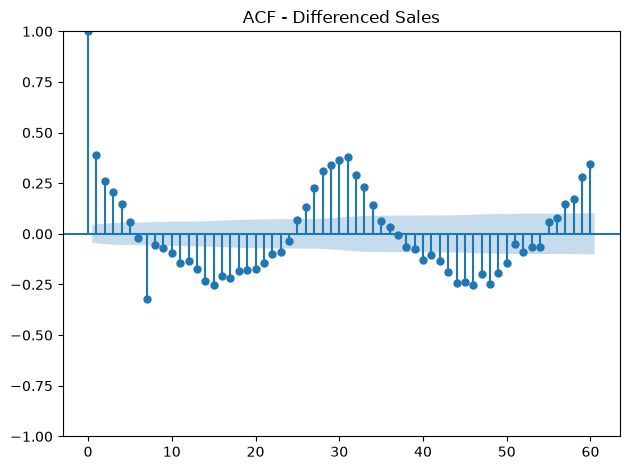

In [52]:
plot_acf(
    sales_diff,
    lags=60
)

plt.title("ACF - Differenced Sales")
plt.tight_layout()
plt.show()

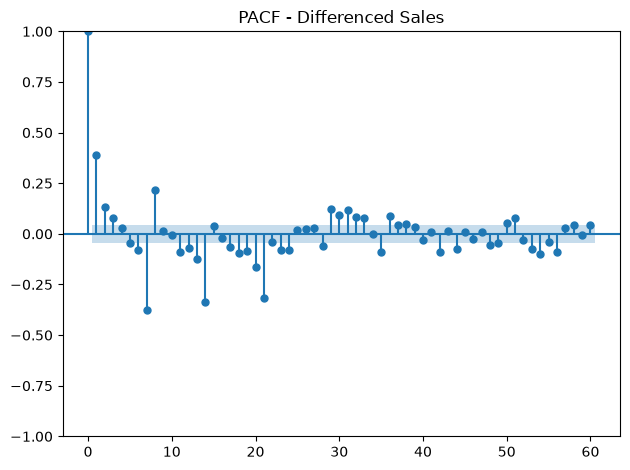

In [53]:
plot_pacf(
    sales_diff,
    lags=60,
    method="ywm"
)

plt.title("PACF - Differenced Sales")
plt.tight_layout()
plt.show()

### 7th and 1st differencing

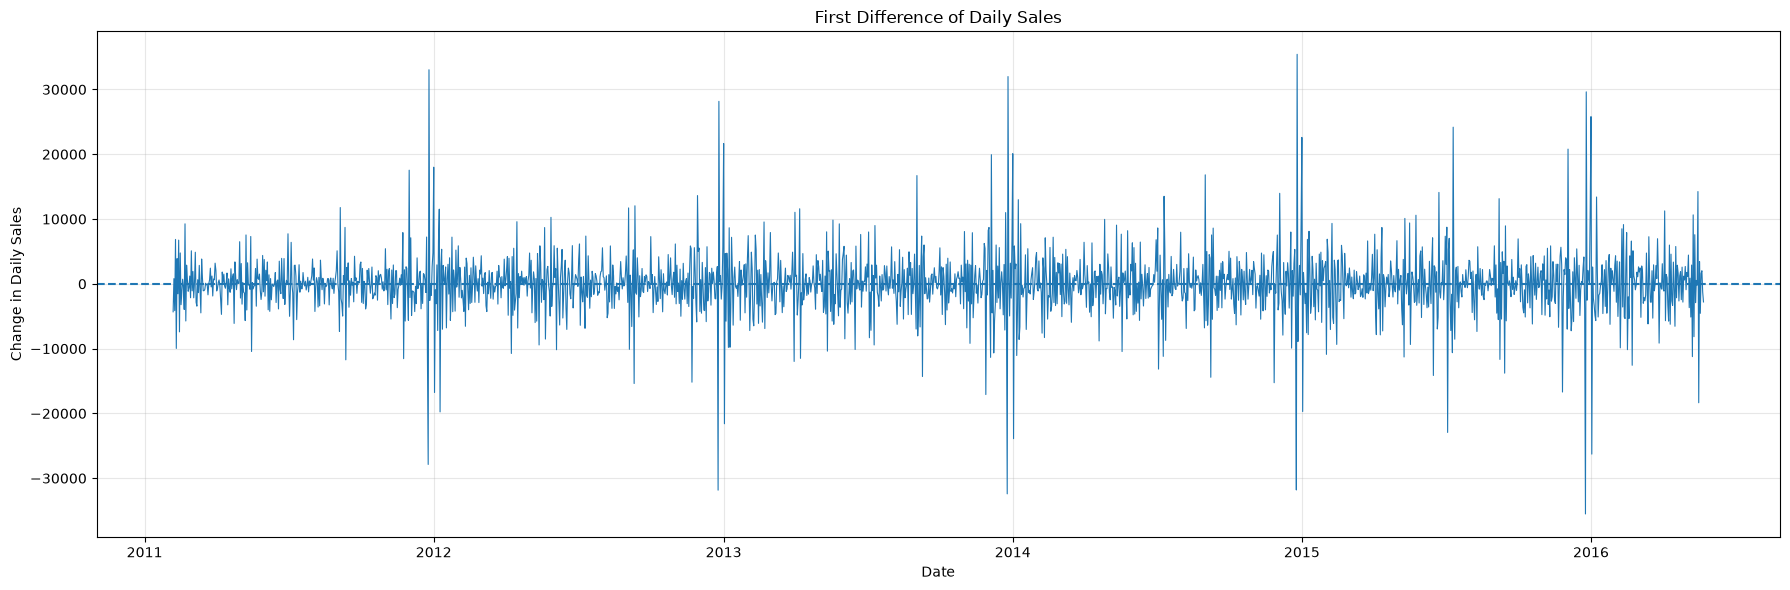

In [59]:
diff_both = (    
    sales_ts
    .diff(7)
    .diff(1)
    .dropna()
)


plt.figure(figsize=(18, 6))

plt.plot(
    diff_both.index,
    diff_both.values,
    linewidth=0.8
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("Date")
plt.ylabel("Change in Daily Sales")
plt.title("First Difference of Daily Sales")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

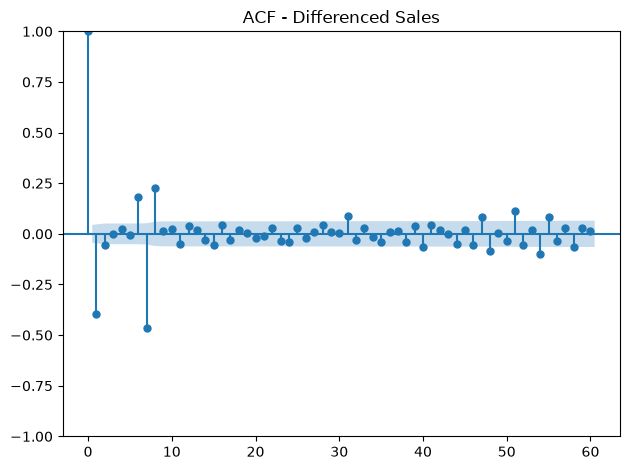

In [60]:
plot_acf(
    diff_both,
    lags=60
)

plt.title("ACF - Differenced Sales")
plt.tight_layout()
plt.show()

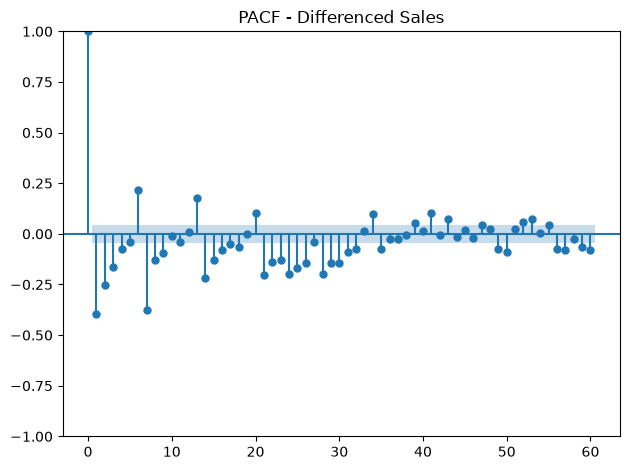

In [61]:
plot_pacf(
    diff_both,
    lags=60,
    method="ywm"
)

plt.title("PACF - Differenced Sales")
plt.tight_layout()
plt.show()

In [63]:
diff_adf = adfuller(diff_both)

print("ADF Statistic:", diff_adf[0])
print("p-value:", diff_adf[1])

ADF Statistic: -21.530861589619374
p-value: 0.0


In [65]:
kpss_result = kpss(
    diff_both.dropna(),
    regression="c",
    nlags="auto"
)

print("KPSS Statistic:", kpss_result[0])
print("p-value:", kpss_result[1])

KPSS Statistic: 0.015318218714793639
p-value: 0.1


C:\Users\thilo\AppData\Local\Temp\ipykernel_8372\363790500.py:1: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_result = kpss(


## Price

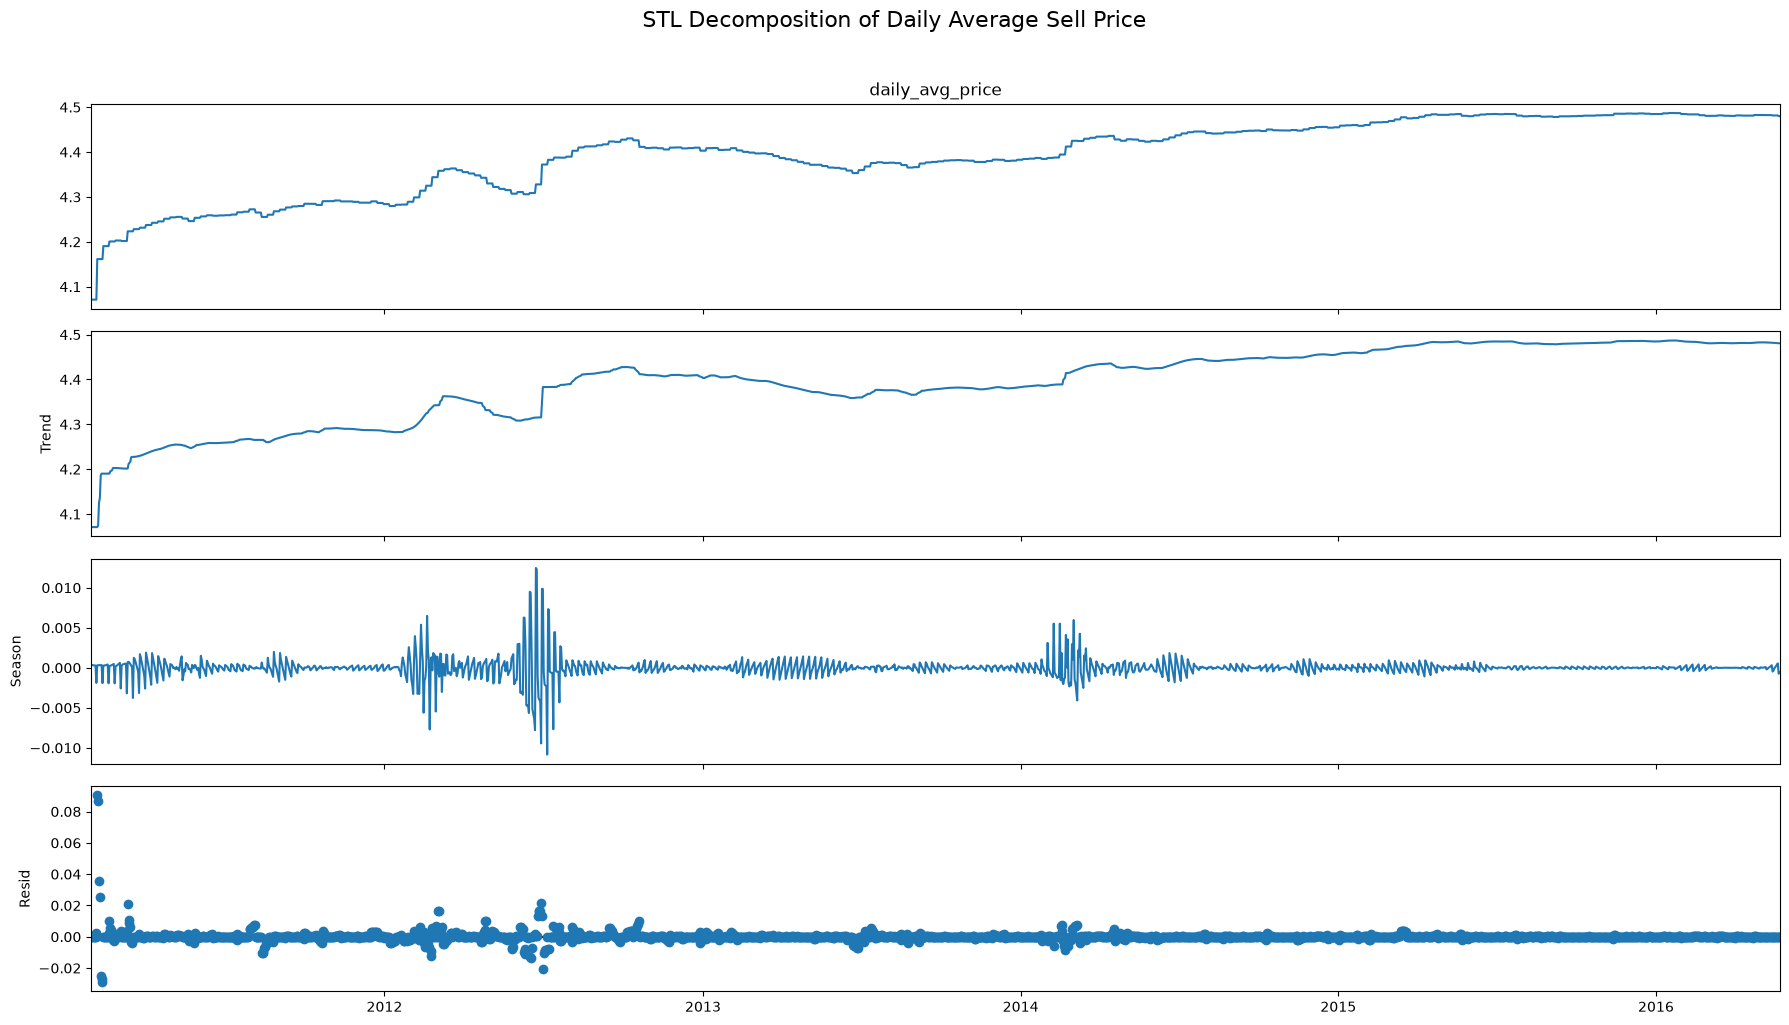

In [66]:
price_stl = STL(
    price_ts,
    period=7,
    robust=True
)

price_result = price_stl.fit()

price_result.plot()

plt.gcf().set_size_inches(18, 10)

plt.suptitle(
    "STL Decomposition of Daily Average Sell Price",
    fontsize=16,
    y=1.02
)

plt.tight_layout()
plt.show()


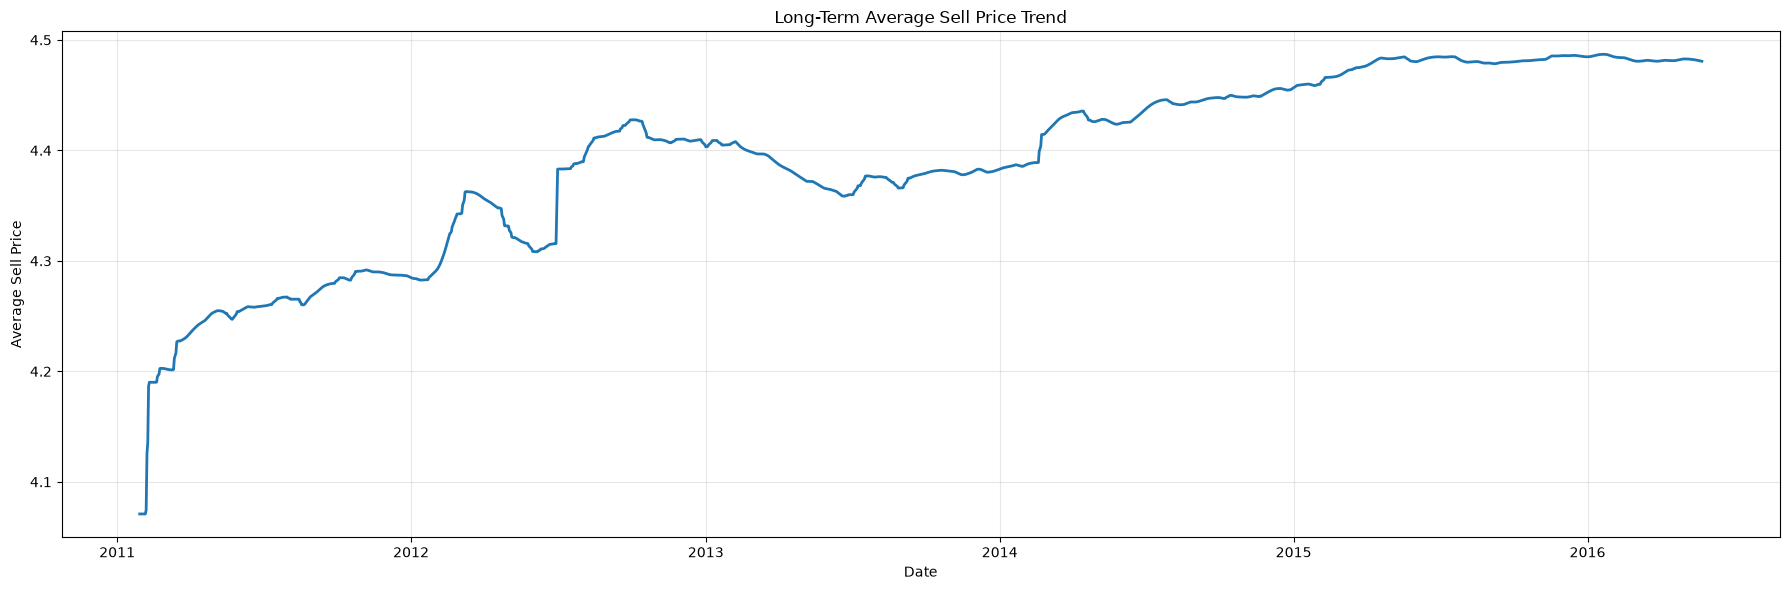

In [67]:
plt.figure(figsize=(18, 6))

plt.plot(
    price_result.trend.index,
    price_result.trend.values,
    linewidth=2
)

plt.xlabel("Date")
plt.ylabel("Average Sell Price")
plt.title("Long-Term Average Sell Price Trend")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

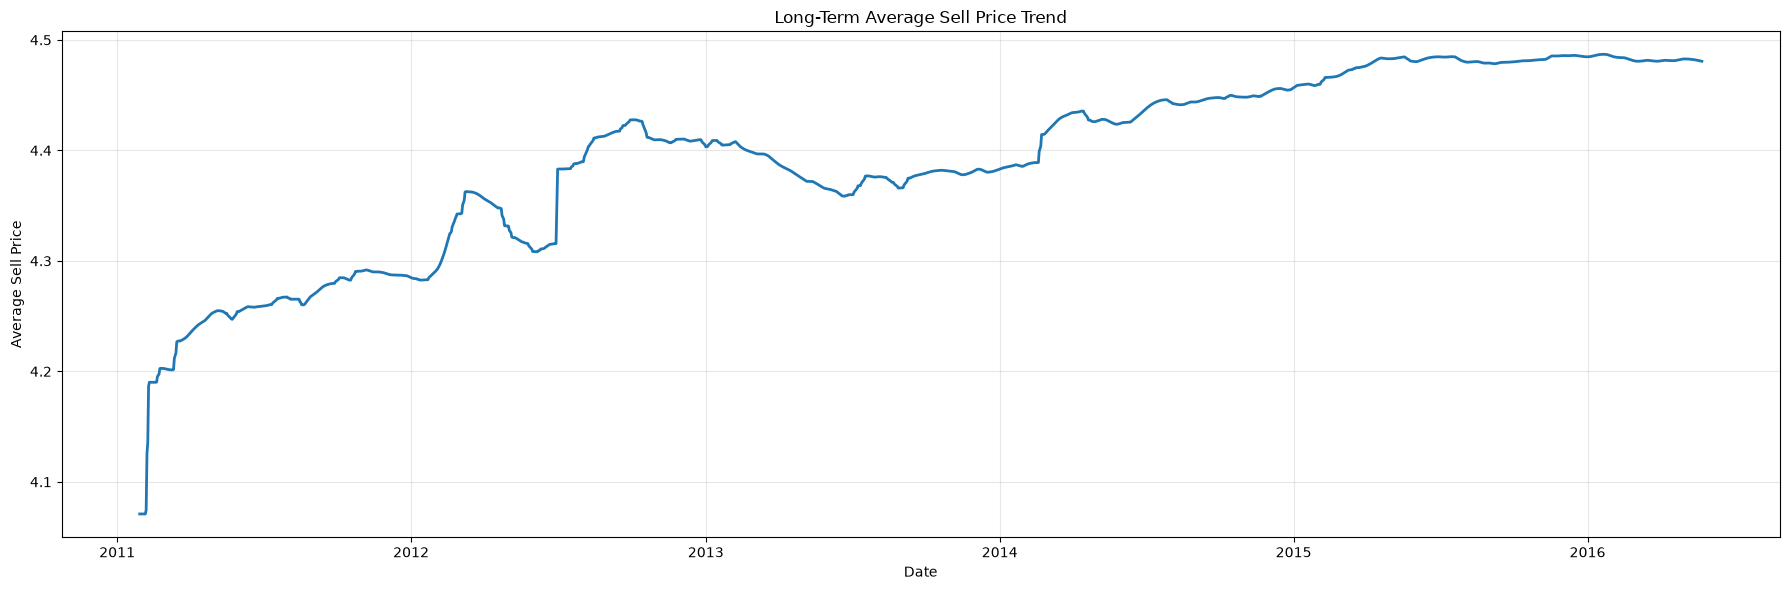

In [68]:
plt.figure(figsize=(18, 6))

plt.plot(
    price_result.trend.index,
    price_result.trend.values,
    linewidth=2
)

plt.xlabel("Date")
plt.ylabel("Average Sell Price")
plt.title("Long-Term Average Sell Price Trend")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

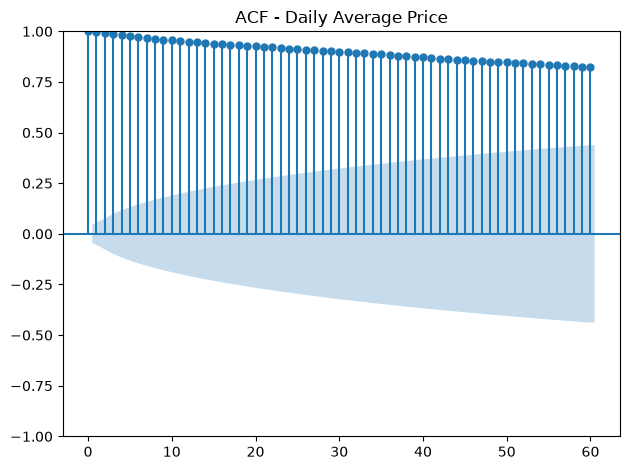

In [69]:
plot_acf(
    price_ts,
    lags=60
)

plt.title("ACF - Daily Average Price")
plt.tight_layout()
plt.show()

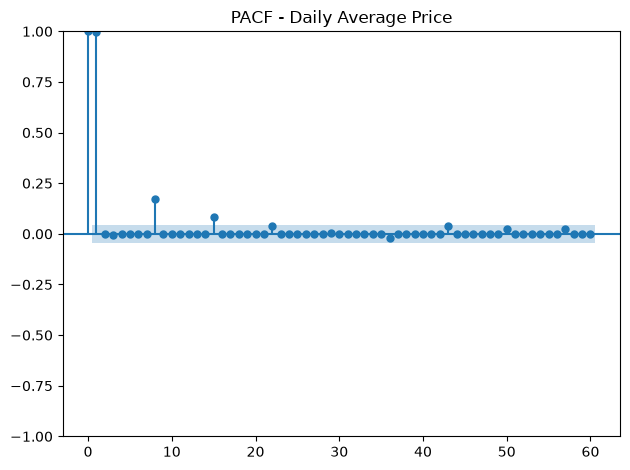

In [70]:
plot_pacf(
    price_ts,
    lags=60,
    method="ywm"
)

plt.title("PACF - Daily Average Price")
plt.tight_layout()
plt.show()

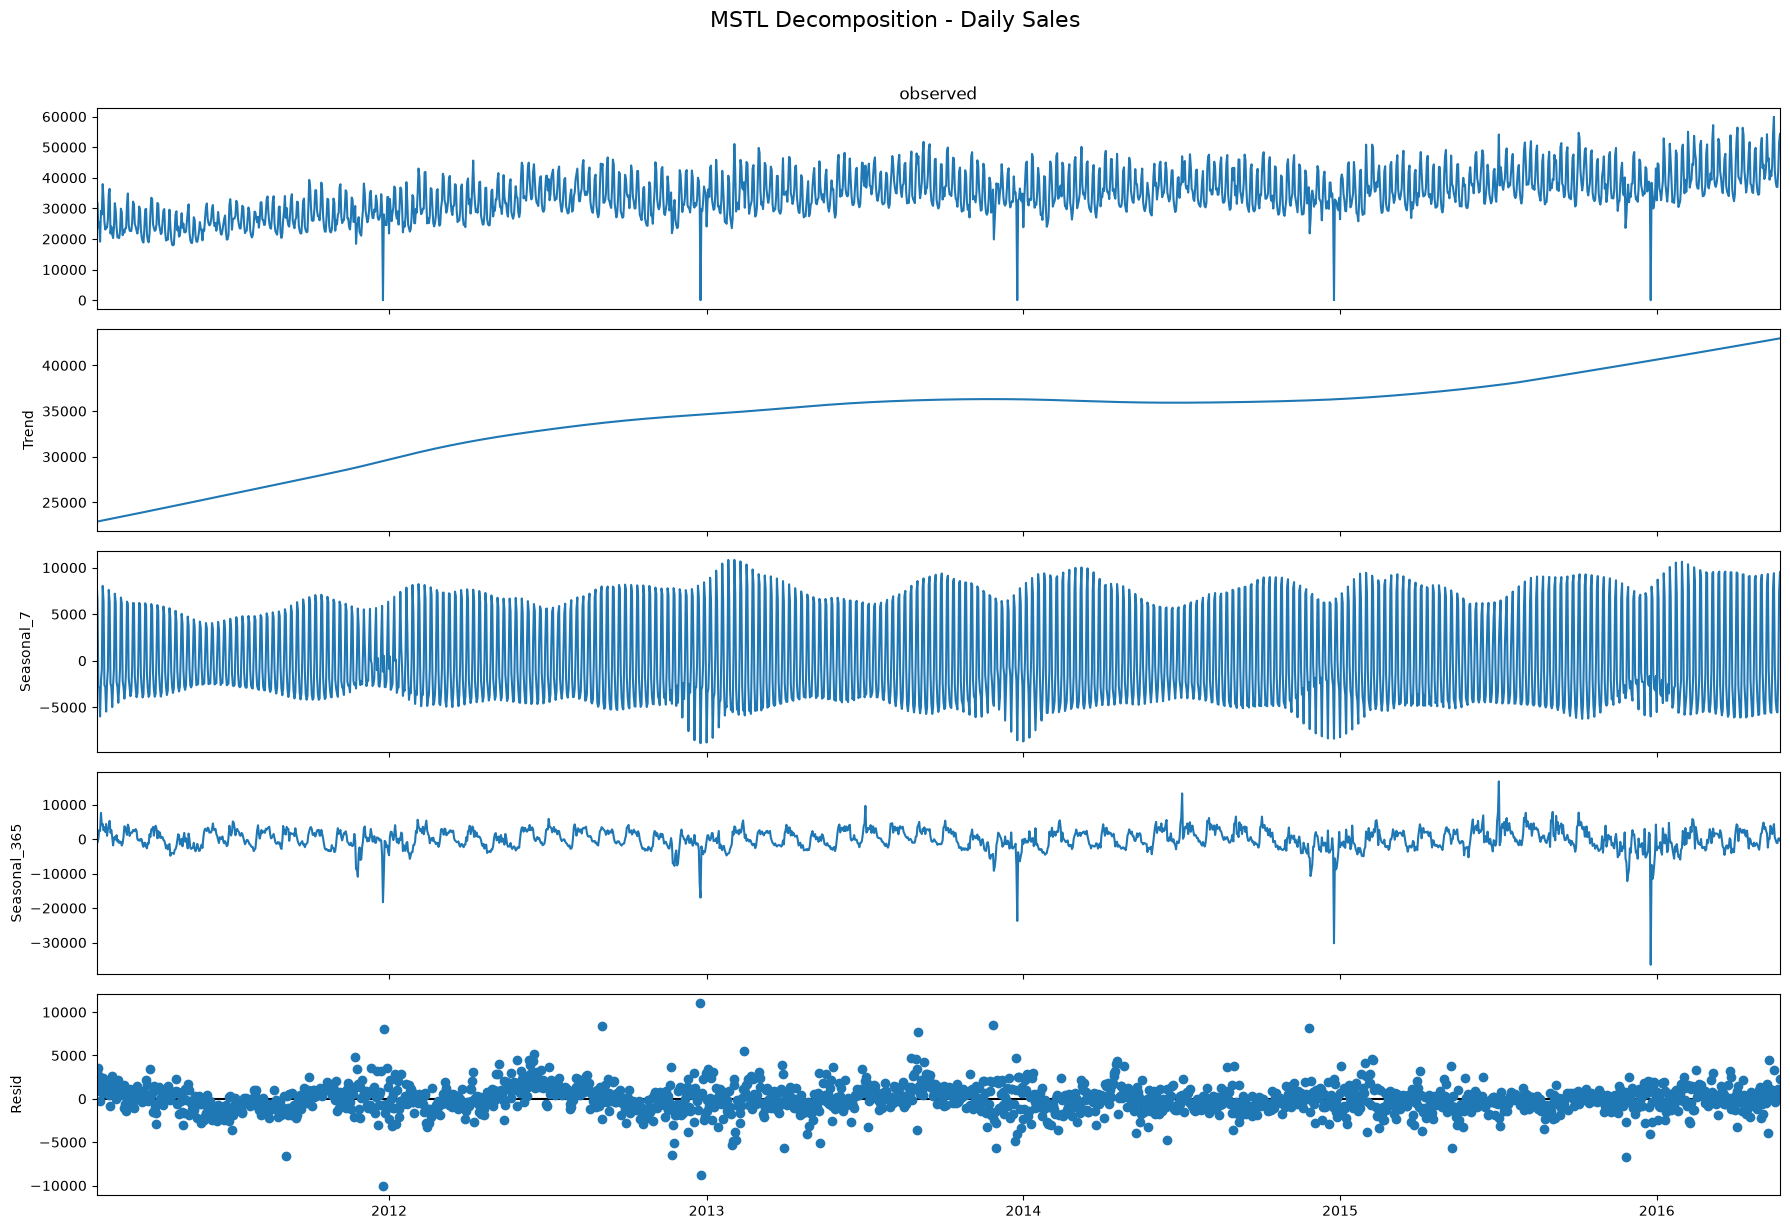

In [71]:
from statsmodels.tsa.seasonal import MSTL

mstl = MSTL(
    sales_ts,
    periods=(7, 365)
)

mstl_result = mstl.fit()

mstl_result.plot()

plt.gcf().set_size_inches(18, 12)
plt.suptitle(
    "MSTL Decomposition - Daily Sales",
    fontsize=16,
    y=1.02
)

plt.tight_layout()
plt.show()

# Base line Model - SARIMA

In [72]:
candidates = [
    # order       seasonal_order
    ((1, 0, 0),  (0, 1, 1, 7)),
    ((0, 0, 1),  (0, 1, 1, 7)),
    ((1, 0, 1),  (0, 1, 1, 7)),
    ((1, 0, 0),  (1, 1, 0, 7)),
    ((0, 0, 1),  (1, 1, 0, 7)),
    ((1, 0, 1),  (1, 1, 1, 7)),
]

In [96]:
daily_summary = daily_summary.sort("date")

train_df = daily_summary.filter(
    pl.col("date") < pl.lit("2016-04-20")
)

test_df = daily_summary.filter(
    pl.col("date") >= pl.lit("2016-04-20")
)

train = train_df.sort("date").to_pandas()["total_daily_sales"]
test = test_df.sort("date").to_pandas()["total_daily_sales"]
train.index = pd.to_datetime(train_df['date'])
test.index = pd.to_datetime(test_df['date'])

In [105]:
train.head() , test.head()

(2011-01-29    32631
 2011-01-30    31749
 2011-01-31    23783
 2011-02-01    25412
 2011-02-02    19146
 Name: total_daily_sales, dtype: int64,
 2016-04-20    35343
 2016-04-21    35033
 2016-04-22    40517
 2016-04-23    48962
 2016-04-24    49795
 Name: total_daily_sales, dtype: int64)

In [118]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

results = []
models = []

for order, seasonal_order in candidates:
    try:
        model = SARIMAX(
            train,
            order=order,
            seasonal_order=seasonal_order,
            enforce_stationarity=False,
            enforce_invertibility=False
        )

        fitted = model.fit(disp=False)

        results.append({
            "order": order,
            "seasonal_order": seasonal_order,
            "AIC": fitted.aic,
            "BIC": fitted.bic
        })
        
        models.append(fitted)

    except Exception as e:
        print(order, seasonal_order, e)

e:\Projects\Dynamic-Pricing---Inventory-Forecasting-Engine\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
e:\Projects\Dynamic-Pricing---Inventory-Forecasting-Engine\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
e:\Projects\Dynamic-Pricing---Inventory-Forecasting-Engine\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
e:\Projects\Dynamic-Pricing---Inventory-Forecasting-Engine\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
e:\Projects\Dynamic-

In [119]:
import pandas as pd

comparison = pd.DataFrame(results)

comparison.sort_values("AIC")

,order,seasonal_order,AIC,BIC
2,"(1, 0, 1)","(0, 1, 1, 7)",35990.146382,36012.327941
5,"(1, 0, 1)","(1, 1, 1, 7)",36164.249680,36191.976629
0,"(1, 0, 0)","(0, 1, 1, 7)",36270.265458,36286.903212
1,"(0, 0, 1)","(0, 1, 1, 7)",36372.801972,36389.438141
3,"(1, 0, 0)","(1, 1, 0, 7)",36591.311362,36607.949117
4,"(0, 0, 1)","(1, 1, 0, 7)",36713.112327,36729.751666


In [120]:
forecasts = []

for model in models:
    forecast = model.forecast(
        steps=len(test)
    )
    forecasts.append(forecast)
    

In [ ]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error
  


MAE : 2644.0495424573614
RMSE: 3372.669914434128

MAE : 2615.4051788724405
RMSE: 3344.4341166301697

MAE : 2799.357601509476
RMSE: 3531.591507466333

MAE : 2710.349070883825
RMSE: 3397.0926283452955

MAE : 2704.0618854934637
RMSE: 3372.3642487069674

MAE : 2817.622981633037
RMSE: 3566.0881041713374



Model 1:
Order: (1, 0, 0), Seasonal Order: (0, 1, 1, 7)
MAE : 2644.0495424573614
RMSE: 3372.669914434128


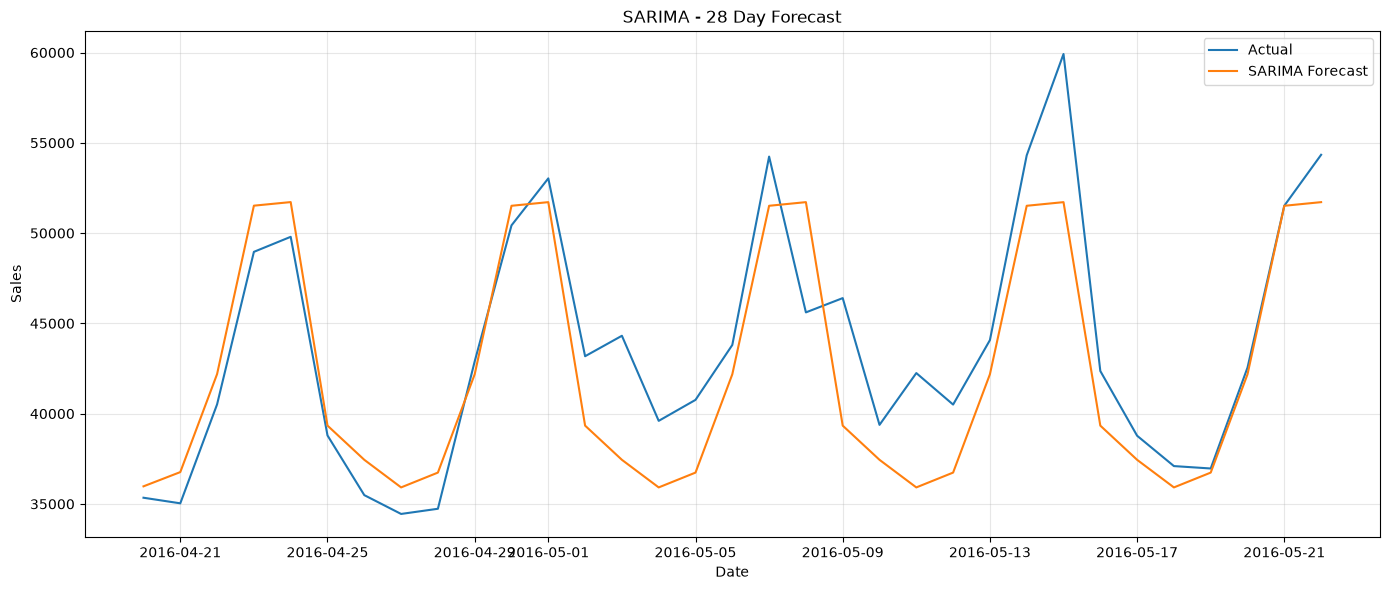


------------------------------------------------------------

Model 2:
Order: (0, 0, 1), Seasonal Order: (0, 1, 1, 7)
MAE : 2615.4051788724405
RMSE: 3344.4341166301697


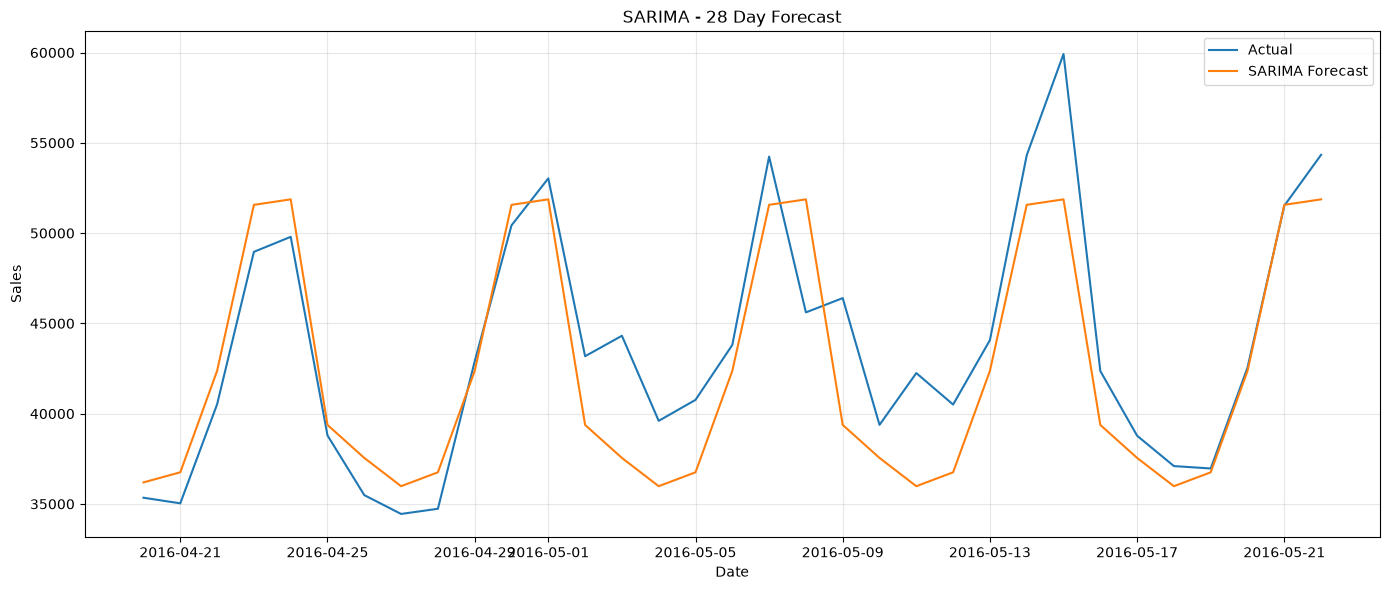


------------------------------------------------------------

Model 3:
Order: (1, 0, 1), Seasonal Order: (0, 1, 1, 7)
MAE : 2799.357601509476
RMSE: 3531.591507466333


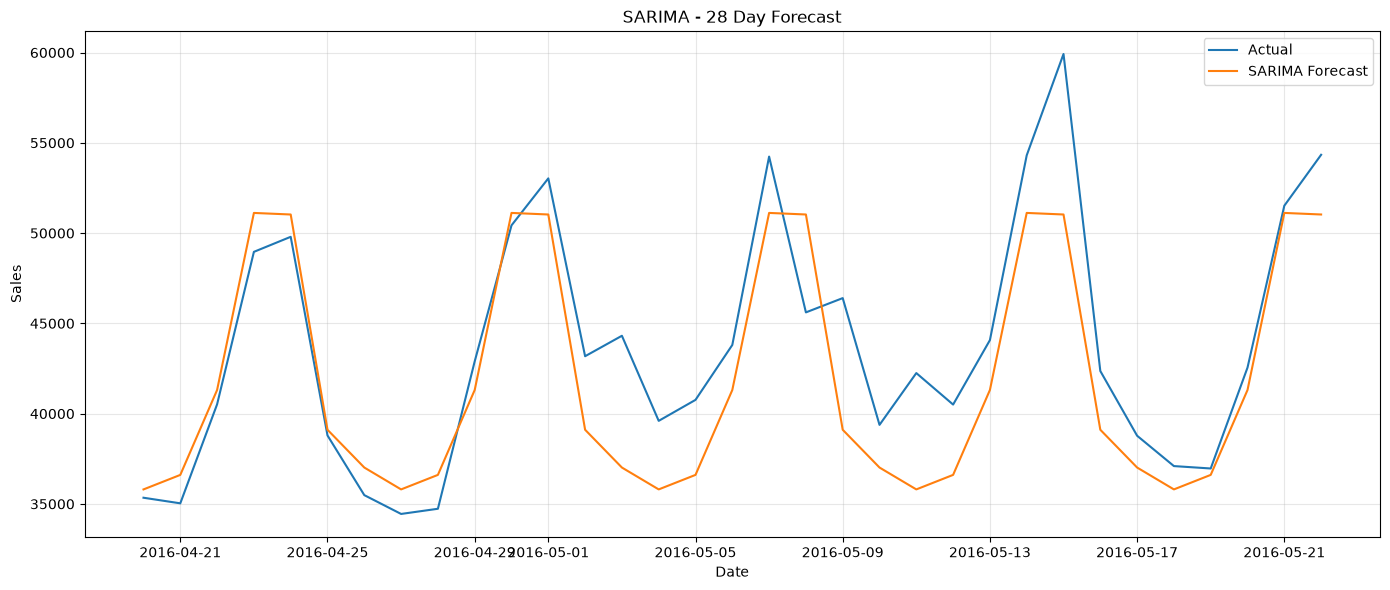


------------------------------------------------------------

Model 4:
Order: (1, 0, 0), Seasonal Order: (1, 1, 0, 7)
MAE : 2710.349070883825
RMSE: 3397.0926283452955


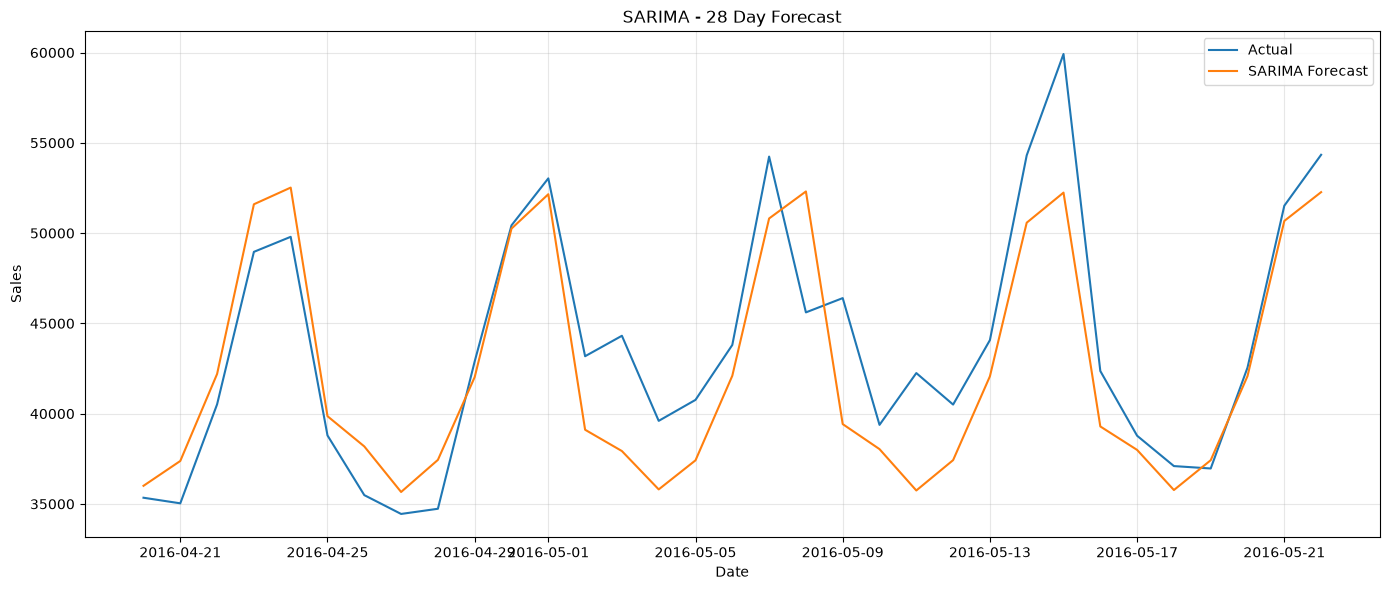


------------------------------------------------------------

Model 5:
Order: (0, 0, 1), Seasonal Order: (1, 1, 0, 7)
MAE : 2704.0618854934637
RMSE: 3372.3642487069674


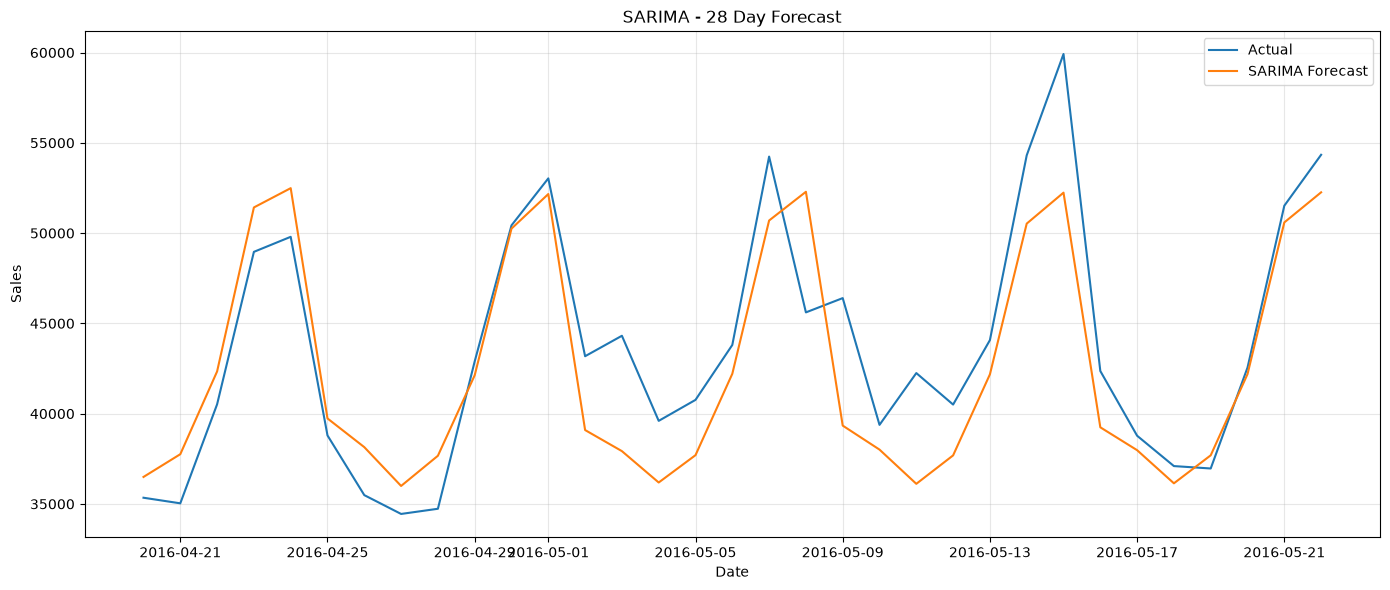


------------------------------------------------------------

Model 6:
Order: (1, 0, 1), Seasonal Order: (1, 1, 1, 7)
MAE : 2817.622981633037
RMSE: 3566.0881041713374


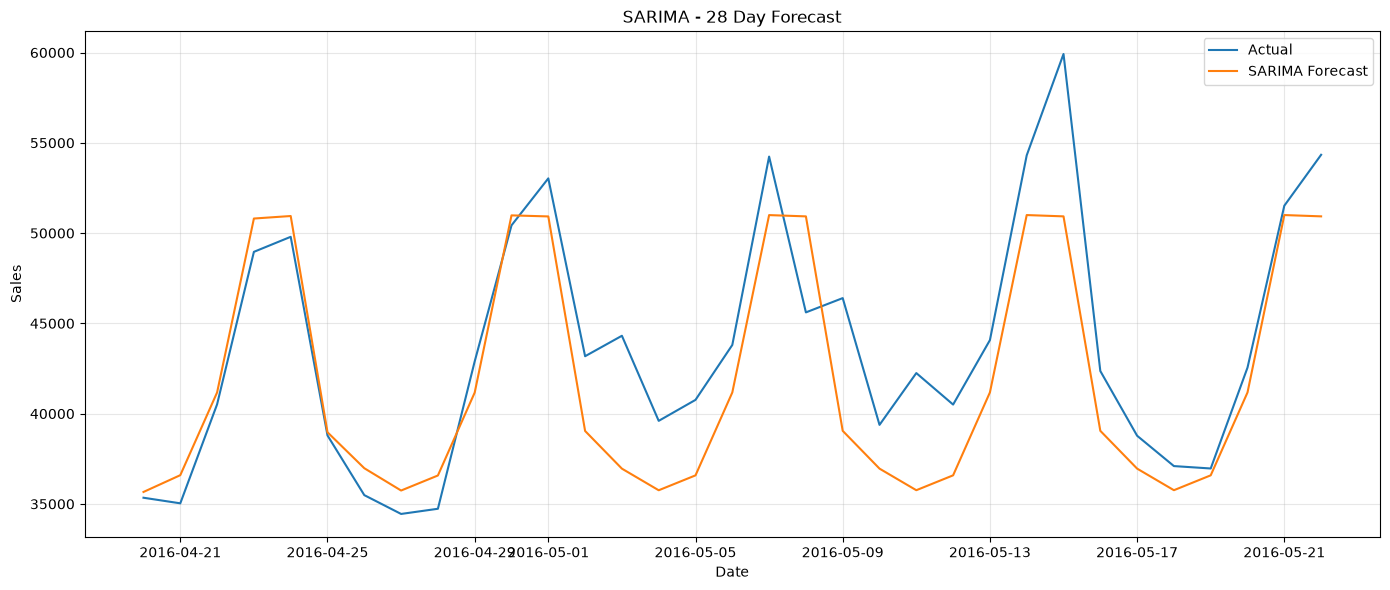


------------------------------------------------------------



In [132]:
import matplotlib.pyplot as plt

for i, forecast in enumerate(forecasts):
    print(f"Model {i+1}:")
    print(f"Order: {comparison.iloc[i]['order']}"
          f", Seasonal Order: {comparison.iloc[i]['seasonal_order']}"
          )
    
    mae = mean_absolute_error(
        test,
        forecast
    )

    rmse = np.sqrt(
        mean_squared_error(
            test,
            forecast
        )
    )
    

    print("MAE :", mae)
    print("RMSE:", rmse)
    plt.figure(figsize=(14, 6))

    plt.plot(
        test.index,
        test.values,
        label="Actual"
    )

    plt.plot(
        test.index,
        forecast.values,
        label="SARIMA Forecast"
    )

    plt.xlabel("Date")
    plt.ylabel("Sales")
    plt.title(f"SARIMA - 28 Day Forecast")


    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
    

    print()
    print('--' *30)
    print()    
